# Exploratory Data Analysis (EDA) – Fake News Project

**Objective:** Perform EDA on Fake.csv and True.csv datasets to understand the data, identify patterns, and guide feature engineering + modeling.

---

## 1. Setup and Data Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

#Add labels (0 = Fake, 1 = Real)

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## 2. Basic Inspection

We check dataset size, structure, missing values, and data types.

In [3]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()

Shape: (44898, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


title      0
text       0
subject    0
date       0
label      0
dtype: int64

## 3. Summary Statistics
Look at distributions of numeric features and create derived features like text length

In [4]:
df["text_length"] = df["text"].apply(len)
df["title_length"] = df["title"].apply(len)

df.describe()

,label,text_length,title_length
count,44898.000000,44898.000000,44898.000000
mean,0.477015,2469.109693,80.111720
std,0.499477,2171.617091,25.379685
min,0.000000,1.000000,8.000000
25%,0.000000,1234.000000,63.000000
50%,0.000000,2186.000000,73.000000
75%,1.000000,3105.000000,91.000000
max,1.000000,51794.000000,286.000000


## 4. Univariate Analysis

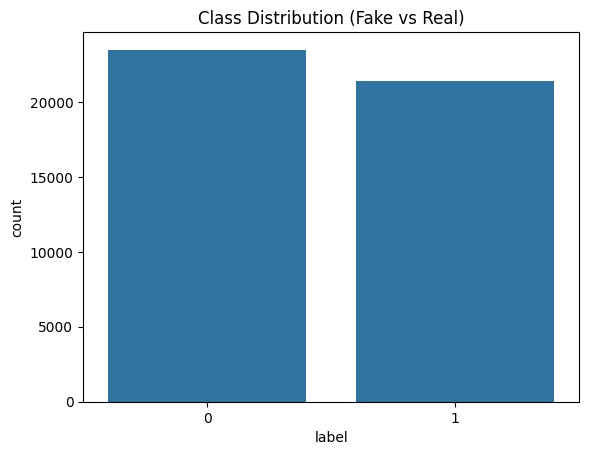

Bar Plot Explanation:
This plot shows the number of fake (label=0) and real (label=1) news articles in the dataset. It helps you see if the dataset is balanced or if one class is more common than the other.



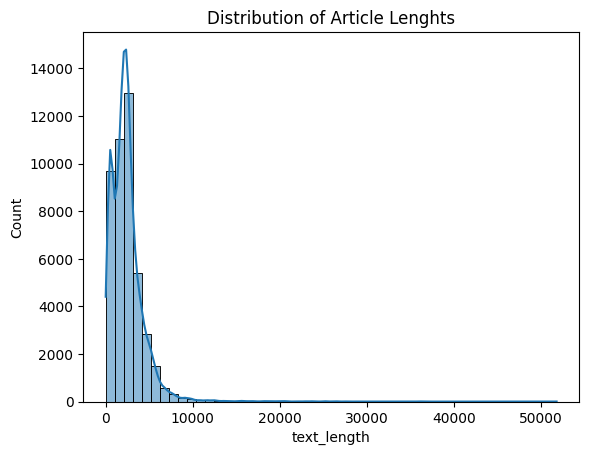

Histogram Explanation:
This plot shows how article lengths are distributed. Each bar represents the number of articles within a specific range of text lengths. This helps you understand what article length is typical, how much variation there is, and whether there are any unusually short or long articles.
Average article length: 2469.1096930820972 characters


In [7]:
#Label distribution
sns.countplot(x = "label", data=df)
plt.title("Class Distribution (Fake vs Real)")
plt.show()
print(
    "Bar Plot Explanation:\n"
    "This plot shows the number of fake (label=0) and real (label=1) news articles in the dataset. "
    "It helps you see if the dataset is balanced or if one class is more common than the other.\n"
)

#Distribution of article length
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution of Article Lenghts")
plt.show()
print(
    "Histogram Explanation:\n"
    "This plot shows how article lengths are distributed. "
    "Each bar represents the number of articles within a specific range of text lengths. "
    "This helps you understand what article length is typical, how much variation there is, and whether there are any unusually short or long articles."
)

average_text_length = df["text_length"].mean()
print(f"Average article length: {average_text_length} characters")


### 5. Bivariate Analysis
Compare features across labels.

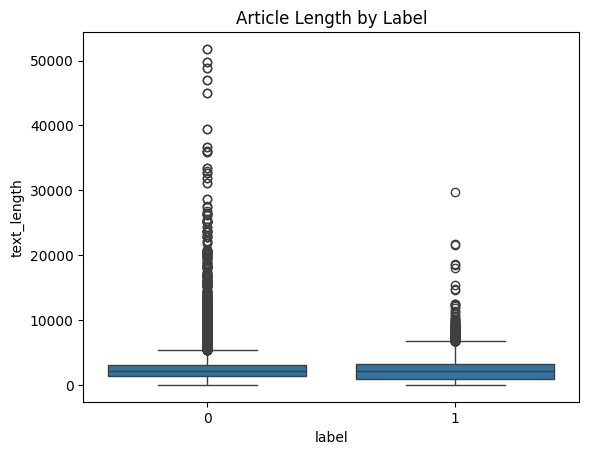

Boxplot Explanation:
This boxplot compares the distribution of article lengths for fake (label=0) and real (label=1) news articles.
It shows the median, quartiles, and potential outliers for each group.
If the boxes are different in height or position, it means the typical article length differs between fake and real news.
Outliers are shown as points outside the whiskers, indicating unusually short or long articles.


In [8]:
sns.boxplot(x = "label", y = "text_length", data=df)
plt.title("Article Length by Label")
plt.show()
print(
    "Boxplot Explanation:\n"
    "This boxplot compares the distribution of article lengths for fake (label=0) and real (label=1) news articles.\n"
    "It shows the median, quartiles, and potential outliers for each group.\n"
    "If the boxes are different in height or position, it means the typical article length differs between fake and real news.\n"
    "Outliers are shown as points outside the whiskers, indicating unusually short or long articles."
)

## 6. Correlation & Covariance

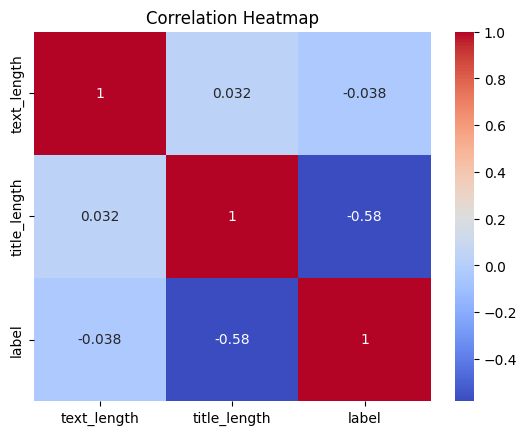

Correlation Heatmap Explanation:
This heatmap shows the correlation coefficients between text length, title length, and label (fake/real).
Values close to 1 or -1 indicate strong positive or negative relationships, respectively.
Values near 0 mean little or no linear relationship.
For example, if text_length and label have a high positive correlation, longer articles are more likely to be real (label=1).


In [9]:
corr = df[["text_length", "title_length", "label"]].corr()
sns.heatmap(corr, annot = True, cmap ="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

df[["text_length", "title_length", "label"]].cov()

print(
    "Correlation Heatmap Explanation:\n"
    "This heatmap shows the correlation coefficients between text length, title length, and label (fake/real).\n"
    "Values close to 1 or -1 indicate strong positive or negative relationships, respectively.\n"
    "Values near 0 mean little or no linear relationship.\n"
    "For example, if text_length and label have a high positive correlation, longer articles are more likely to be real (label=1)."
)


## 7. Mutual Information (Feature vs Target)

In [10]:

from sklearn.feature_selection import mutual_info_classif

X = df[["text_length", "title_length"]]
y = df["label"]

mi = mutual_info_classif(X, y, discrete_features=False)
mi_scores = pd.Series(mi, index=X.columns)

# Print the scores with explanation
print("Mutual Information Scores:")
print(mi_scores)
print(
    "\nExplanation:\n"
    "Mutual information measures how much knowing a feature (like text length or title length) helps predict the target (fake or real).\n"
    "Higher values mean the feature is more informative for classification.\n"
    "In these results, title_length is more informative for predicting whether an article is fake or real than text_length.\n"
    "Both features provide some information, but title_length is more useful for distinguishing between fake and real news in this dataset."
)

Mutual Information Scores:
text_length     0.090127
title_length    0.311073
dtype: float64

Explanation:
Mutual information measures how much knowing a feature (like text length or title length) helps predict the target (fake or real).
Higher values mean the feature is more informative for classification.
In these results, title_length is more informative for predicting whether an article is fake or real than text_length.
Both features provide some information, but title_length is more useful for distinguishing between fake and real news in this dataset.


## 8. Word-Level Analysis
Most frequent words in fake vs real articles

In [11]:
from collections import Counter
import re

def get_top_words(texts, n = 20):
    words = " ".join(texts).lower()
    words = re.findall(r"\w+", words)
    return Counter(words).most_common(n)

print("Top Fake Words:", get_top_words(fake["text"], 20))
print("Top Real Words:", get_top_words(true["text"], 20))

Top Fake Words: [('the', 543551), ('to', 290819), ('of', 236640), ('and', 226971), ('a', 214783), ('in', 171163), ('that', 151662), ('s', 141155), ('is', 111234), ('for', 93480), ('on', 83591), ('it', 83380), ('trump', 79300), ('he', 78997), ('was', 67857), ('with', 63419), ('his', 58351), ('this', 58217), ('as', 57768), ('be', 49271)]
Top Real Words: [('the', 482468), ('to', 245734), ('of', 205275), ('a', 198580), ('and', 182081), ('in', 181652), ('s', 141421), ('on', 108594), ('said', 99062), ('that', 88237), ('for', 79895), ('is', 55494), ('trump', 54700), ('with', 54504), ('he', 54370), ('it', 49590), ('by', 47949), ('was', 47946), ('as', 47330), ('has', 46246)]
